<a href="https://colab.research.google.com/github/PPRRAATTIIKK/ChatBot/blob/main/chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
import pandas as pd
import numpy as np
import json
import nltk
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, GlobalMaxPooling1D, Flatten
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

In [5]:
with open('/content/intents.json') as intent:
    data = json.load(intent)

In [6]:
tag = []
inputs = []
response = {}
for intent in data['intents']:
    response[intent['tag']] = intent['responses']
    for line in intent['patterns']:
        inputs.append(line)
        tag.append(intent['tag'])

data = pd.DataFrame({'patterns': inputs, 'tags': tag})

In [7]:
data
response

{'greeting': ['Hello, thanks for asking',
  'Good to see you again',
  'Hi there, how can I help?'],
 'goodbye': ['See you!', 'Have a nice day', 'Bye! Come back again soon.'],
 'thanks': ['Happy to help!', 'Any time!', 'My pleasure'],
 'noanswer': ["Sorry, can't understand you",
  'Please give me more info',
  'Not sure I understand'],
 'options': ['I can guide you through Adverse drug reaction list, Blood pressure tracking, Hospitals and Pharmacies',
  'Offering support for Adverse drug reaction, Blood pressure, Hospitals and Pharmacies'],
 'adverse_drug': ['Navigating to Adverse drug reaction module'],
 'blood_pressure': ['Navigating to Blood Pressure module'],
 'blood_pressure_search': ['Please provide Patient ID', 'Patient ID?'],
 'search_blood_pressure_by_patient_id': ['Loading Blood pressure result for Patient'],
 'pharmacy_search': ['Please provide pharmacy name'],
 'search_pharmacy_by_name': ['Loading pharmacy details'],
 'hospital_search': ['Please provide hospital name or loc

In [8]:
import string

data['patterns'] = data['patterns'].apply(lambda wrd:[ltrs.lower() for ltrs in wrd if ltrs not in string.punctuation])
data['patterns'] = data['patterns'].apply(lambda wrd: ''.join(wrd))
data.head(5)

,patterns,tags
0,hi there,greeting
1,how are you,greeting
2,is anyone there,greeting
3,hey,greeting
4,hola,greeting


In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer

toknizer = Tokenizer(num_words = 2000)
toknizer.fit_on_texts(data['patterns'])
train = toknizer.texts_to_sequences(data['patterns'])

In [10]:
# Apply padding

from tensorflow.keras.preprocessing.sequence import pad_sequences

x_train = pad_sequences(train)

In [11]:
# encode the output

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(data['tags'])

In [12]:
input_shape = x_train.shape[1]
print(input_shape)

9


In [13]:
# define vocabulary

vocabulary = len(toknizer.word_index)
print(f' No of unique words: {vocabulary}')

output_length = le.classes_.shape[0]
print(f' Output length: {output_length}')

 No of unique words: 89
 Output length: 9


In [14]:
# create the model

i = Input(shape=(input_shape,))
x = Embedding(vocabulary+1, 10)(i)
x = LSTM(10, return_sequences=True)(x)
x = Flatten()(x)
x = Dense(output_length, activation = "softmax")(x)
model = Model(i, x)

In [15]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

In [16]:
train = model.fit(x_train, y_train, epochs=200)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.0638 - loss: 2.1963
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1702 - loss: 2.1937
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3191 - loss: 2.1912
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3830 - loss: 2.1888
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3191 - loss: 2.1863
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3191 - loss: 2.1837
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3191 - loss: 2.1808
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3191 - loss: 2.1777
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2766 - loss: 2.1743
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2553 - loss: 2.1707
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2553 - loss: 2.1670
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2553 - lo

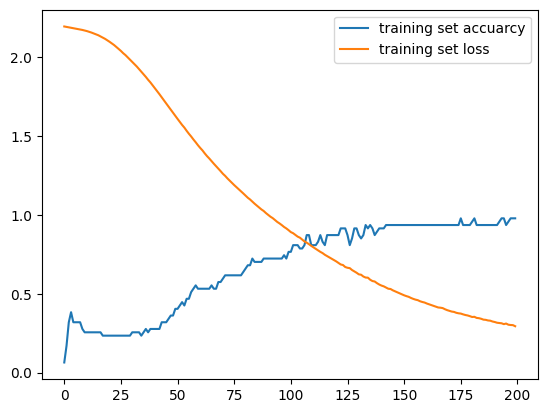

In [17]:
# Accuray

plt.plot(train.history['accuracy'], label='training set accuarcy')
plt.plot(train.history['loss'], label='training set loss')
plt.legend()

In [ ]:
# Testing
import random

while True:

    text_p = []
    prediction_input = input('>> ')

    # remove punctuation
    prediction_input = [letters.lower() for letters in prediction_input if letters not in string.punctuation]
    prediction_input = ''.join(prediction_input)
    text_p.append(prediction_input)

    # Tokenization
    prediction_input = toknizer.texts_to_sequences(text_p)
    prediction_input  = np.array(prediction_input).reshape(-1)
    prediction_input  = pad_sequences([prediction_input], input_shape)

    # Greeting
    output = model.predict(prediction_input)
    output = output.argmax()

    # finding the right tag and prediction
    response_tag = le.inverse_transform([output])[0]
    print('sam : ', random.choice(response[response_tag]))
    if response_tag == 'goodbay':
        break

>> HELLO
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
sam :  Hi there, how can I help?
>> hows the weather
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
sam :  My pleasure
>> how are you
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
sam :  Hello, thanks for asking
>> what are you doin
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
sam :  Have a nice day
>> bye
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
sam :  Bye! Come back again soon.
